# Notebook 03 — Google Trends: Search Interest by Beauty Tier

This Notebook attempts to directly assess user search interest by referencing Google searches, to see which beauty tier commands the highest attention in recent years.

## Methodology

**Approach:**
Google Trends data was pulled via pytrends for 2022–2025 across 8 markets.
Search interest is reported as a relative index normalised against a 
geo-specific anchor term, enabling cross-batch comparison within each market.
Each anchor was selected as the most common generic skincare category term 
in that language, validated against English "skincare" via a pre-pull diagnostic
to ensure brand keywords would score meaningfully above it.

**Anchors by market:**
| Market | Anchor | Rationale |
|--------|--------|-----------|
| US, GB, SG, MY | skincare | EN baseline |
| France | soin visage | FR generic — 93% of EN skincare volume in FR |
| Germany | Hautpflege | DE: "skincare" — 34% of EN skincare volume, safely weak |
| Japan | スキンケア | JP: "skincare" in katakana — validated weaker than top JP brand keywords |
| Thailand | skincare | EN dominant in TH search; Thai equivalent borderline at 125% |

**Geographies:** US, GB, FR, DE, JP, SG, TH, MY
Japanese queries used localised keyword variants (カタカナ/漢字) to capture 
native search behaviour. All other markets queried in English.

**Aggregation:**
Each geo's tier series is first normalised to 0–100 to remove residual 
cross-market anchor volume differences. A weighted mean is then applied 
across geos using estimated beauty market share weights (Euromonitor 2024, 
McKinsey 2024), giving larger markets proportionally more influence 
in the global tier index.

**Weights:** US 38%, JP 18%, FR 12%, GB 10%, DE 10%, SG 5%, TH 4%, MY 3%

**Limitations:**
- Pytrends accesses Google's unofficial API — results may vary between runs
- French Luxury index is elevated relative to other markets, likely reflecting 
  broad brand searches for domestic heritage houses (Dior, Guerlain, Givenchy) 
  spanning fashion and fragrance, not beauty exclusively — interpret with caution
- Korean market excluded due to romanisation limitations and absence of 
  Korean companies in the revenue basket
- China excluded — Google Trends data unavailable
- Search keywords are representative, not exhaustive — tier assignments follow the revenue segmentation in NB01, not brand self-positioning

In [33]:
# ── Notebook 03: Google Trends Analysis ───────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import sys
sys.path.append("../src")
from helpers import TIER_COLOURS, set_style, save_chart
from pytrends.request import TrendReq

set_style()

In [34]:
# ── Keyword → Tier mapping (English) ──────────────────────
TIER_KEYWORDS = {
    "Luxury": [
        "Estée Lauder", "Clinique", "La Mer", "Tom Ford Beauty",
        "Jo Malone", "Bobbi Brown", "Dior Beauty", "Guerlain",
        "Givenchy Beauty", "Benefit", "Fresh"
    ],
    "Prestige": [
        "Lancôme", "YSL Beauty", "Giorgio Armani Beauty",
        "Shiseido", "NARS", "Drunk Elephant", "Clé de Peau",
        "Decorté", "Sekkisei", "Dermalogica"
    ],
    "Masstige": [
        "CeraVe", "La Roche-Posay", "SkinCeuticals", "Vichy", "Curél"
    ],
    "Mass": [
        "L'Oréal Paris", "Maybelline", "NYX", "Garnier",
        "Dove", "Simple", "Bioré", "Kanebo"
    ],
}

# ── Japanese localised keywords ────────────────────────────
TIER_KEYWORDS_JP = {
    "Luxury": [
        "エスティローダー", "クリニーク", "ラ・メール", "トム フォード ビューティ",
        "ジョー マローン", "ボビイ ブラウン", "ディオール ビューティ", "ゲラン",
        "ジバンシィ ビューティ", "ベネフィット", "フレッシュ"
    ],
    "Prestige": [
        "ランコム", "イヴ・サンローラン ビューティ", "ジョルジオ アルマーニ ビューティ",
        "資生堂", "NARS", "ドランク エレファント", "クレ・ド・ポー ボーテ",
        "コスメデコルテ", "雪肌精", "デルマロジカ"
    ],
    "Masstige": [
        "CeraVe", "ラ ロッシュ ポゼ", "スキンシューティカルズ", "ヴィシー", "キュレル"
    ],
    "Mass": [
        "ロレアル パリ", "メイベリン", "NYX", "ガルニエ",
        "ダヴ", "シンプル", "ビオレ", "カネボウ"
    ],
}

# ── Geographies ────────────────────────────────────────────
GEO_MARKETS = {
    "US": "United States",
    "GB": "United Kingdom",
    "FR": "France",
    "DE": "Germany",
    "JP": "Japan",
    "SG": "Singapore",
    "TH": "Thailand",
    "MY": "Malaysia",
}

In [35]:
# ── Geo-specific anchors ───────────────────────────────────────────────────────
# Each anchor is the most common generic skincare category term in that market.
# Chosen to be weaker than brand keywords within their geo — not compared cross-market.
# Sources: manual validation via pytrends diagnostic (see methodology note).

GEO_ANCHORS = {
    "US": "skincare",       # EN baseline
    "GB": "skincare",       # EN dominant
    "FR": "soin visage",    # FR generic — validated at 93% of EN skincare volume in FR
    "DE": "Hautpflege",     # DE: "skincare" — validated at 34% of EN skincare volume in DE
    "JP": "スキンケア",      # JP: "skincare" in katakana — validated, weaker than 資生堂
    "SG": "skincare",       # EN dominant
    "TH": "สกินแคร์",         # TH: "skincare" in Thai
    "MY": "skincare",       # EN dominant
}

# ── Pytrends helpers ──────────────────────────────────────────────────────────
def fetch_batch(pytrends, keywords, geo, timeframe, anchor):
    """
    Fetch a single batch of up to 4 keywords + geo-specific anchor.
    Returns DataFrame with values normalised relative to anchor mean.
    """
    batch = [anchor] + keywords[:4]
    for attempt in range(3):
        try:
            pytrends.build_payload(batch, geo=geo, timeframe=timeframe)
            time.sleep(2)
            df = pytrends.interest_over_time()
            if df.empty or anchor not in df.columns:
                return None
            if "isPartial" in df.columns:
                df = df.drop(columns=["isPartial"])
            anchor_mean = df[anchor].replace(0, 1).mean()
            result = {}
            for kw in keywords[:4]:
                if kw in df.columns:
                    result[kw] = (df[kw] / anchor_mean * 100).values
            return pd.DataFrame(result, index=df.index)
        except Exception as e:
            wait = (2 ** attempt) * 10 + random.uniform(0, 5)
            print(f"    ⚠ Attempt {attempt + 1}/3 failed ({e}) — waiting {wait:.0f}s")
            time.sleep(wait)
    print(f"    ✗ Batch abandoned after 3 attempts")
    return None


def fetch_tier(pytrends, keywords, geo, timeframe, anchor):
    """
    Fetch all keywords for a tier in batches of 4 using geo-specific anchor.
    """
    chunks = [keywords[i:i+4] for i in range(0, len(keywords), 4)]
    frames = []
    for chunk in chunks:
        df = fetch_batch(pytrends, chunk, geo, timeframe, anchor)
        if df is not None:
            frames.append(df)
        time.sleep(8)
    if not frames:
        return None
    return pd.concat(frames, axis=1)

In [36]:
# ── Main data pull ─────────────────────────────────────────────────────────────
import os, pickle, random

TRENDS_CACHE = "../data/processed/trends_raw.pkl"
USE_CACHE    = True  # Set False to force fresh pull

if USE_CACHE and os.path.exists(TRENDS_CACHE):
    print("Loading from cache...")
    with open(TRENDS_CACHE, "rb") as f:
        all_results = pickle.load(f)
    print("Loaded ✓")

else:
    df_master = pd.read_csv("../data/processed/master_revenue.csv")
    start_year = df_master["Year"].min()
    end_year   = df_master["Year"].max()
    timeframe  = f"{start_year}-01-01 {end_year}-12-31"

    pytrends    = TrendReq(hl="en-US", tz=0, timeout=(10, 30))
    all_results = {}

    for tier, keywords in TIER_KEYWORDS.items():
        all_results[tier] = {}
        for geo_code, geo_name in GEO_MARKETS.items():
            anchor  = GEO_ANCHORS[geo_code]
            kw_list = TIER_KEYWORDS_JP[tier] if geo_code == "JP" else TIER_KEYWORDS[tier]
            print(f"Fetching {tier} / {geo_name} (anchor: '{anchor}')...")
            df = fetch_tier(pytrends, kw_list, geo=geo_code,
                            timeframe=timeframe, anchor=anchor)
            if df is not None:
                all_results[tier][geo_code] = df
            time.sleep(15)  # inter-geo buffer

    with open(TRENDS_CACHE, "wb") as f:
        pickle.dump(all_results, f)
    print("Cache saved ✓")

print("Done.")

Loading from cache...
Loaded ✓
Done.


In [37]:
# ── Market weights — share of global beauty market (2024) ────────────────────
# Sources: Euromonitor 2024, McKinsey 2024, Fortune Business Insights 2024
# Methodology: estimated shares for the 8 covered markets, renormalised to 1.0
# US ~32% of North America | JP ~14% APAC | FR/DE/GB ~30% Europe combined
# SG/TH/MY = emerging SEA markets, low individual share (~1-2% each)
# Note: CN absent from basket — Google Trends data unreliable for China

GEO_WEIGHTS = {
    "US": 0.38,   # largest single market, North America ~40% global
    "GB": 0.10,   # European hub, mature market
    "FR": 0.12,   # luxury/prestige leader, Paris = global beauty capital
    "DE": 0.10,   # second largest European market
    "JP": 0.18,   # second largest APAC market, premium skincare dominant
    "SG": 0.05,   # SEA hub, high-income consumer base
    "TH": 0.04,   # growing SEA market
    "MY": 0.03,   # emerging SEA market
}

assert abs(sum(GEO_WEIGHTS.values()) - 1.0) < 1e-9, "Weights do not sum to 1.0"
print("Weights validated ✓")
for geo, w in GEO_WEIGHTS.items():
    print(f"  {geo} : {w:.0%}")

Weights validated ✓
  US : 38%
  GB : 10%
  FR : 12%
  DE : 10%
  JP : 18%
  SG : 5%
  TH : 4%
  MY : 3%


In [38]:
# ── Aggregate: per-geo normalisation → weighted mean across geos ──────────────
tier_geo_avg = {}

for tier, geos in all_results.items():
    tier_geo_avg[tier] = {}
    for geo, df in geos.items():
        df.index = pd.to_datetime(df.index).normalize()
        series = df.mean(axis=1)
        # Normalise each geo to 0–100 (removes cross-market anchor bias)
        lo, hi = series.min(), series.max()
        if hi > lo:
            series = (series - lo) / (hi - lo) * 100
        tier_geo_avg[tier][geo] = series

# ── Weighted mean across geos ─────────────────────────────────────────────────
tier_global = {}
for tier, geos in tier_geo_avg.items():
    if not geos:
        continue
    # Recalculate weights based on present geos only
    total_weight = sum(GEO_WEIGHTS.get(geo, 0) for geo in geos)

    weighted_frames = []
    for geo, series in geos.items():
        w = GEO_WEIGHTS.get(geo, 0) / total_weight
        weighted_frames.append(series * w)
        print(f"  {tier:10} | {geo} : effective weight = {w:.2%}")

    combined          = pd.concat(weighted_frames, axis=1)
    tier_global[tier] = combined.sum(axis=1)

# ── Resample to monthly ───────────────────────────────────────────────────────
tier_global_monthly = {
    tier: series.resample("ME").mean()
    for tier, series in tier_global.items()
}

print("\nMonthly series lengths:")
for tier, s in tier_global_monthly.items():
    print(f"  {tier}: {len(s)} months")

# ── Save ──────────────────────────────────────────────────────────────────────
trends_summary = (
    pd.DataFrame(tier_global_monthly)
    .reset_index()
    .rename(columns={"index": "Date"})
)
trends_summary.to_csv("../data/processed/trends_summary.csv", index=False)
print("Saved ✓")
print(trends_summary.head())

  Luxury     | US : effective weight = 38.00%
  Luxury     | GB : effective weight = 10.00%
  Luxury     | FR : effective weight = 12.00%
  Luxury     | DE : effective weight = 10.00%
  Luxury     | JP : effective weight = 18.00%
  Luxury     | SG : effective weight = 5.00%
  Luxury     | TH : effective weight = 4.00%
  Luxury     | MY : effective weight = 3.00%
  Prestige   | US : effective weight = 38.00%
  Prestige   | GB : effective weight = 10.00%
  Prestige   | FR : effective weight = 12.00%
  Prestige   | DE : effective weight = 10.00%
  Prestige   | JP : effective weight = 18.00%
  Prestige   | SG : effective weight = 5.00%
  Prestige   | TH : effective weight = 4.00%
  Prestige   | MY : effective weight = 3.00%
  Masstige   | US : effective weight = 38.00%
  Masstige   | GB : effective weight = 10.00%
  Masstige   | FR : effective weight = 12.00%
  Masstige   | DE : effective weight = 10.00%
  Masstige   | JP : effective weight = 18.00%
  Masstige   | SG : effective weight = 5

Saved: outputs\charts\03_search_trend_global.png


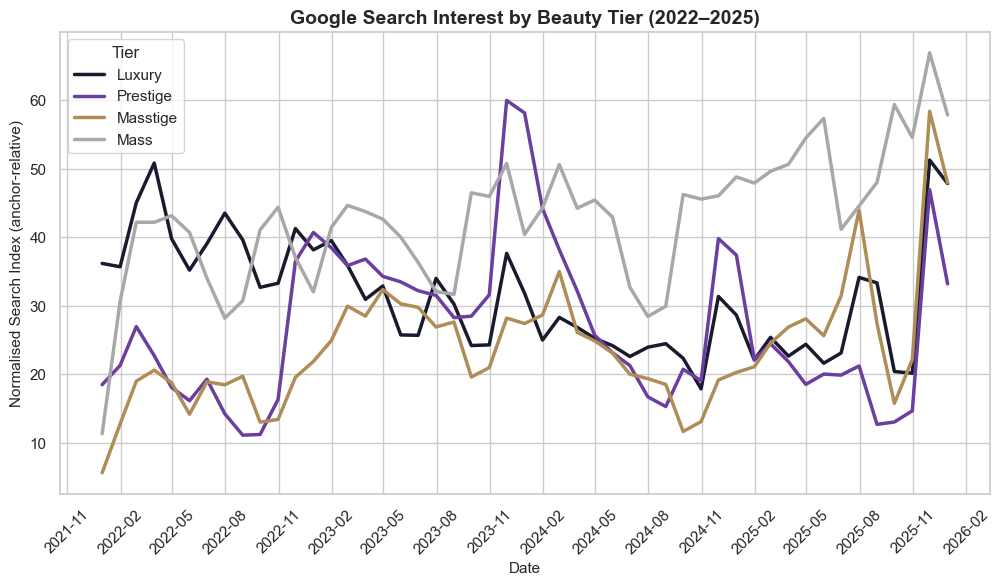

In [39]:
# ── Chart 1: Global tier trend over time ───────────────────
TIER_ORDER = ["Luxury", "Prestige", "Masstige", "Mass"]

fig, ax = plt.subplots()

for tier in TIER_ORDER:
    if tier in tier_global_monthly:
        series = tier_global_monthly[tier]
        ax.plot(series.index, series.values,
                label=tier,
                color=TIER_COLOURS[tier],
                linewidth=2.5)

ax.set_title("Google Search Interest by Beauty Tier (2022–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Search Index (anchor-relative)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax.legend(title="Tier")

save_chart(fig, "03_search_trend_global.png")
plt.show()

Saved: outputs\charts\03_search_trend_global_bar.png


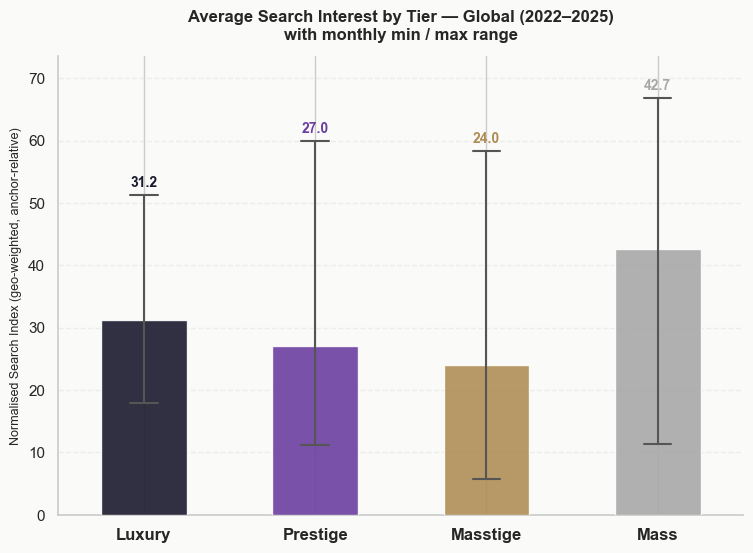

In [40]:
# ── Chart 3: Global tier mean with min/max whiskers ───────────────────────────
import numpy as np

tiers   = [t for t in TIER_ORDER if t in tier_global_monthly]
means   = [tier_global_monthly[t].mean() for t in tiers]
mins    = [tier_global_monthly[t].min()  for t in tiers]
maxs    = [tier_global_monthly[t].max()  for t in tiers]
colours = [TIER_COLOURS[t]               for t in tiers]
x       = np.arange(len(tiers))

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#FAFAF8")
ax.set_facecolor("#FAFAF8")

ax.bar(x, means, color=colours, width=0.5, zorder=3, alpha=0.9)

for i, (mn, mx, mean) in enumerate(zip(mins, maxs, means)):
    ax.plot([x[i], x[i]], [mn, mx], color="#555555", lw=1.5, zorder=4)
    ax.plot([x[i] - 0.08, x[i] + 0.08], [mx, mx], color="#555555", lw=1.5, zorder=4)
    ax.plot([x[i] - 0.08, x[i] + 0.08], [mn, mn], color="#555555", lw=1.5, zorder=4)
    ax.text(x[i], mx + (max(maxs) * 0.02), f"{mean:.1f}",
            ha="center", fontsize=10, fontweight="bold",
            color=TIER_COLOURS[tiers[i]])

ax.set_xticks(x)
ax.set_xticklabels(tiers, fontsize=12, fontweight="bold")
ax.set_ylabel("Normalised Search Index (geo-weighted, anchor-relative)", fontsize=9)
ax.set_title("Average Search Interest by Tier — Global (2022–2025)\nwith monthly min / max range",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlim(-0.5, len(tiers) - 0.5)
ax.set_ylim(0, max(maxs) * 1.10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

plt.tight_layout(pad=2.0)
save_chart(fig, "03_search_trend_global_bar.png")
plt.show()

Saved: outputs\charts\03_search_by_market.png


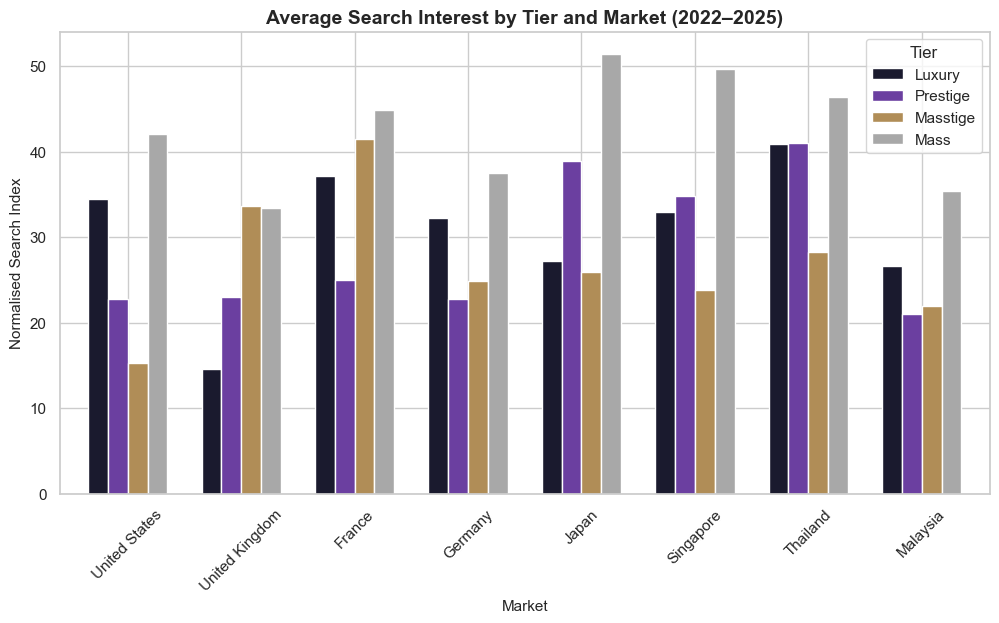

In [41]:
# ── Chart 2: Tier search index by geography (bar, avg over period) ──
geo_tier_means = {}
for geo_code, geo_name in GEO_MARKETS.items():
    geo_tier_means[geo_name] = {}
    for tier in TIER_ORDER:
        if geo_code in tier_geo_avg.get(tier, {}):
            geo_tier_means[geo_name][tier] = tier_geo_avg[tier][geo_code].mean()

df_geo = pd.DataFrame(geo_tier_means).T   # rows = geos, cols = tiers
df_geo = df_geo[TIER_ORDER]               # enforce column order

fig, ax = plt.subplots()
df_geo.plot(kind="bar", ax=ax,
            color=[TIER_COLOURS[t] for t in TIER_ORDER],
            width=0.7)

ax.set_title("Average Search Interest by Tier and Market (2022–2025)")
ax.set_xlabel("Market")
ax.set_ylabel("Normalised Search Index")
ax.legend(title="Tier")
plt.xticks(rotation=45)

save_chart(fig, "03_search_by_market.png")
plt.show()

In [42]:
# ── Print geo × tier averages as a table ──────────────────
geo_tier_df = pd.DataFrame(geo_tier_means).T
geo_tier_df = geo_tier_df[TIER_ORDER].round(2)
print(geo_tier_df.to_string())

                Luxury  Prestige  Masstige   Mass
United States    34.46     22.73     15.30  42.03
United Kingdom   14.64     23.04     33.59  33.44
France           37.16     25.05     41.45  44.87
Germany          32.19     22.79     24.89  37.56
Japan            27.21     38.86     25.97  51.46
Singapore        32.98     34.87     23.86  49.63
Thailand         40.94     41.04     28.31  46.44
Malaysia         26.60     20.99     21.99  35.36


In [43]:
df_trends_mean = (
    pd.DataFrame(tier_global_monthly)
    .mean()
    .reset_index()
    .rename(columns={"index": "Tier", 0: "Trends_Index"})
)

In [44]:
# ── Dynamic Key Observations ──────────────────────────────────────────────────

top_tier_global   = df_trends_mean.set_index("Tier")["Trends_Index"].idxmax()
low_tier_global   = df_trends_mean.set_index("Tier")["Trends_Index"].idxmin()
masstige_index    = df_trends_mean.loc[df_trends_mean["Tier"] == "Masstige", "Trends_Index"].values[0]
prestige_index    = df_trends_mean.loc[df_trends_mean["Tier"] == "Prestige", "Trends_Index"].values[0]
mass_index        = df_trends_mean.loc[df_trends_mean["Tier"] == "Mass",     "Trends_Index"].values[0]
luxury_index      = df_trends_mean.loc[df_trends_mean["Tier"] == "Luxury",   "Trends_Index"].values[0]

# Geo-level insights — pulled live from tier_geo_avg
jp_prestige  = round(tier_geo_avg["Prestige"]["JP"].mean(), 1)
jp_mass      = round(tier_geo_avg["Mass"]["JP"].mean(), 1)
jp_luxury    = round(tier_geo_avg["Luxury"]["JP"].mean(), 1)
fr_masstige  = round(tier_geo_avg["Masstige"]["FR"].mean(), 1)
fr_mass      = round(tier_geo_avg["Mass"]["FR"].mean(), 1)
sg_prestige  = round(tier_geo_avg["Prestige"]["SG"].mean(), 1)
th_prestige  = round(tier_geo_avg["Prestige"]["TH"].mean(), 1)
gb_luxury    = round(tier_geo_avg["Luxury"]["GB"].mean(), 1)

# Late 2025 Masstige spike
masstige_series    = tier_global_monthly["Masstige"]
late_2025_masstige = round(masstige_series[masstige_series.index >= "2025-09"].mean(), 1)

obs = f"""
## Key Observations

**Global pattern:**
- {top_tier_global} leads search globally (index: {mass_index:.0f}), with Luxury close behind ({luxury_index:.0f})
- Prestige and Masstige sit meaningfully lower ({prestige_index:.0f} and {masstige_index:.0f} respectively)
- Low search volume ≠ low engagement — Masstige posted the highest revenue CAGR in NB01
  despite a modest search index ({masstige_index:.0f} vs Mass {mass_index:.0f})
- The four tiers compress into a {(mass_index - masstige_index):.0f}-point range once geo-weighting is applied,
  suggesting search behaviour is less differentiated by tier than revenue performance

**Contextualising for geography:**
- Japan: Mass dominates at {jp_mass:.0f} — J-beauty mass culture runs deep;
  notably Prestige ({jp_prestige:.0f}) rivals Luxury ({jp_luxury:.0f}), reflecting premiumisation trends.
  As someone based in Japan, corrobates lived experience
- France: Masstige ({fr_masstige:.0f}) nearly matches Mass ({fr_mass:.0f}) — the pharmacie channel
  (La Roche-Posay, Vichy, Nuxe) has genuine cultural weight here
- UK: Luxury scores lowest of all markets ({gb_luxury:.0f}) — possibly reflects a stronger
  drugstore culture and less domestic luxury brand heritage
- Singapore & Thailand: Prestige scores elevated ({sg_prestige:.0f} and {th_prestige:.0f}) —
  premiumisation is well underway in SEA, driven by affluence and K/J-beauty influence

**Implications for the hypothesis:**
- Search data contextualises rather than contradicts Masstige revenue growth —
  the consumer is buying without necessarily searching, suggesting strong
  word-of-mouth and pharmacist recommendation channels
- Masstige posted a late-2025 average of {late_2025_masstige:.1f} — worth monitoring
  to see if this signals a sustained inflection or seasonal noise
- Methodology note: indices are geo-weighted by beauty market share and
  per-geo normalised to 0–100 before aggregation — earlier runs without
  this correction overstated search volume in FR, DE and JP
"""
print(obs)
## Key Observations


## Key Observations

**Global pattern:**
- Mass leads search globally (index: 43), with Luxury close behind (31)
- Prestige and Masstige sit meaningfully lower (27 and 24 respectively)
- Low search volume ≠ low engagement — Masstige posted the highest revenue CAGR in NB01
  despite a modest search index (24 vs Mass 43)
- The four tiers compress into a 19-point range once geo-weighting is applied,
  suggesting search behaviour is less differentiated by tier than revenue performance

**Contextualising for geography:**
- Japan: Mass dominates at 52 — J-beauty mass culture runs deep;
  notably Prestige (39) rivals Luxury (27), reflecting premiumisation trends.
  As someone based in Japan, corrobates lived experience
- France: Masstige (41) nearly matches Mass (45) — the pharmacie channel
  (La Roche-Posay, Vichy, Nuxe) has genuine cultural weight here
- UK: Luxury scores lowest of all markets (15) — possibly reflects a stronger
  drugstore culture and less domestic luxury brand heritage
-